# **Computer Vision libraries in Pytorch**

In [1]:
# Importing pytorch
import torch
from torch import nn

# Importing torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Importing matplotlib
import matplotlib.pyplot as plt

# Checking versions
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


In [2]:
# Getting the training and testing data
train_data = datasets.FashionMNIST(root="data",
                                   train=True,
                                   download=True,
                                   transform=ToTensor(),
                                   target_transform=None
)

test_data = datasets.FashionMNIST(root="data",
                                  train=False,
                                  download=True,
                                  transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


In [3]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

# **Input and Output shapes**

In [4]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [5]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
# Classes
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

# **Visualizing the data**

Shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

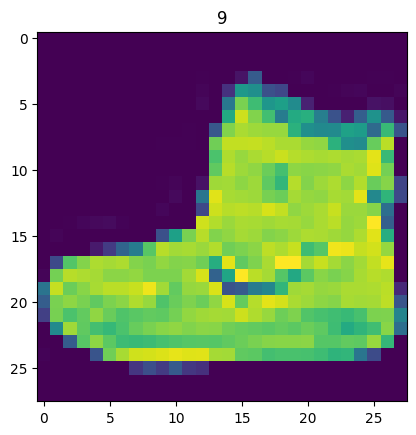

In [9]:
# Visualizing the data
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

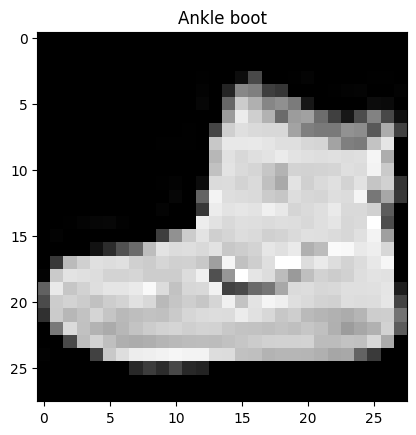

In [10]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(classes[label])

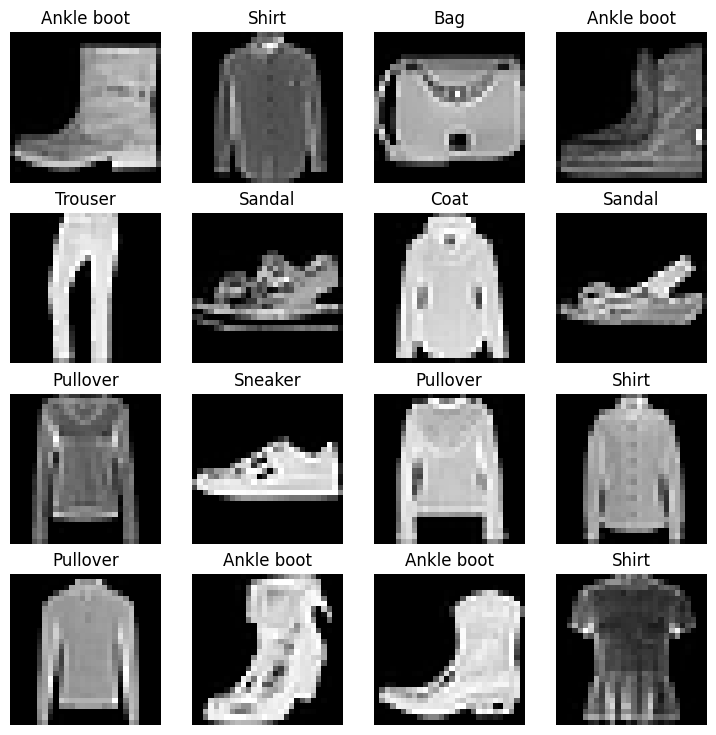

In [11]:
# Plot random images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(classes[label])
  plt.axis(False)

# **Using the dataloader**

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

print(f"Dataloaders: {train_dataloader}, {test_dataloader}")
print(f"Length of Train dataloader: {len(train_dataloader)}, Batch size: {BATCH_SIZE}")
print(f"Length of Test dataloader: {len(test_dataloader)}, Batch size: {BATCH_SIZE}")

Dataloaders: <torch.utils.data.dataloader.DataLoader object at 0x78ef680745f0>, <torch.utils.data.dataloader.DataLoader object at 0x78ef61f9ac60>
Length of Train dataloader: 1875, Batch size: 32
Length of Test dataloader: 313, Batch size: 32


In [13]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch, train_features_batch.shape, train_labels_batch, train_labels_batch.shape

(tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0000, 0.0039],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

Image size: torch.Size([1, 28, 28])
Label: 6, Label size: torch.Size([])


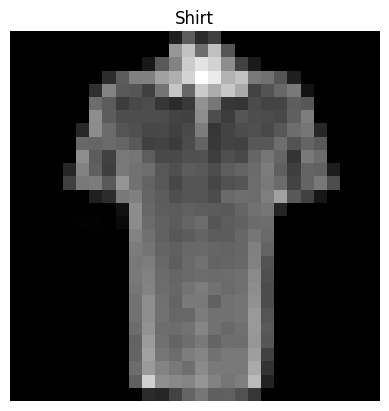

In [14]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(classes[label])
plt.axis("Off")
print(f"Image size: {img.shape}")
print(f"Label: {label}, Label size: {label.shape}")

# **Building the model**

In [15]:
# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
# Create a flatten layer
flatten_layer = nn.Flatten()

x = train_features_batch[0]

output = flatten_layer(x)

print(f"X: {x}, Shape: {x.shape}")
print(f"Output: {output}, Shape: {output.shape}")

X: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078, 0.0000,
          0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.00

In [17]:
# Building the model
class FashionMNISTModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.layers_stack = nn.Sequential(
        nn.Flatten(), # neural networks like inputs in vector form
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layers_stack(x)

In [18]:
# Instantiating the model
torch.manual_seed(42)

model_0 = FashionMNISTModel(input_shape=784,
                            hidden_units=10,
                            output_shape=len(classes)).to(device)
model_0, model_0.parameters(), next(model_0.parameters()).device

(FashionMNISTModel(
   (layers_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=10, bias=True)
     (2): Linear(in_features=10, out_features=10, bias=True)
   )
 ),
 <generator object Module.parameters at 0x78ef61cdce40>,
 device(type='cpu'))

# **Loss function and optimizer**

In [19]:
# Importing helper_functions.py
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

Download helper_functions.py


In [20]:
# Loss function and optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [21]:
# Timing the training and testing
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device=None):
  total_time = end - start
  print(f"Train time on {device}, {total_time:.3f} seconds")
  return total_time

In [22]:
# Testing the timing function
start_time = timer()
# Code here
end_time = timer()
print_train_time(start_time, end_time, device="cpu")

Train time on cpu, 0.000 seconds


3.332699998281896e-05

# **Training and testing**

In [23]:
# Training and testing
from tqdm.auto import tqdm

torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------")

  train_loss = 0
  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()

    y_preds = model_0(X)

    loss = loss_fn(y_preds, y)

    train_loss += loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  if batch%400 == 0:
    print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

  # Testing the model
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X,y in test_dataloader:
      test_preds = model_0(X)

      test_loss += loss_fn(test_preds, y)

      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))

    test_loss /= len(test_dataloader)

    test_acc /= len(test_dataloader)

  print(f"\nTrain loss: {train_loss:.5f}, Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------

Train loss: 0.59039, Test loss: 0.50954, Test accuracy: 82.04%

Epoch: 1
--------

Train loss: 0.47633, Test loss: 0.47989, Test accuracy: 83.20%

Epoch: 2
--------

Train loss: 0.45503, Test loss: 0.47664, Test accuracy: 83.43%

Train time on cpu, 29.730 seconds


# **Making predictions on the trained model_0**

In [24]:
# Making predictions on the trained model_0
torch.manual_seed(42)

def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
  loss, acc = 0, 0

  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)

      y_preds = model(X)

      loss += loss_fn(y_preds, y)
      acc += accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

# **Improving the model**

In [25]:
# Device agnostic code
import torch
from torch import nn

device  = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [26]:
# Building the model_1
class FashionMNISTModel1(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.layers_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x: torch.Tensor):
    return self.layers_stack(x)

In [27]:
# Instantiating the model
torch.manual_seed(42)
model_1 = FashionMNISTModel1(input_shape=784, hidden_units=8, output_shape=len(classes)).to(device)
model_1, next(model_1.parameters()).device

(FashionMNISTModel1(
   (layers_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=8, bias=True)
     (2): ReLU()
     (3): Linear(in_features=8, out_features=10, bias=True)
     (4): ReLU()
   )
 ),
 device(type='cpu'))

# **Loss function and optimizer**

In [28]:
# Loss function and optimizer
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

# **Functionizing training and testing loops**

In [29]:
# Functionizing training and testing loops
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer,
               accuracy_fn, device: torch.device=device):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_preds = model(X)

    loss = loss_fn(y_preds, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f}, Train accuracy: {train_acc:.2f}%")

def test_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module, accuracy_fn,
              device: torch.device=device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      test_preds = model(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%")

# **Training and testing the model**

In [30]:
# Training and testing the model
torch.manual_seed(42)

from timeit import default_timer as timer

train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------")
  train_step(model=model_1, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)

  test_step(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)

train_time_end_on_cpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 0.91913, Train accuracy: 66.24%
Test loss: 0.73198, Test accuracy: 72.89%
Epoch: 1
--------
Train loss: 0.61420, Train accuracy: 77.61%
Test loss: 0.50056, Test accuracy: 81.80%
Epoch: 2
--------
Train loss: 0.46734, Train accuracy: 83.34%
Test loss: 0.50745, Test accuracy: 82.43%
Train time on cpu, 31.455 seconds


In [31]:
model_0_results

{'model_name': 'FashionMNISTModel',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [32]:
train_time_model_0

29.730288954000002

# **Evaluating the model**

In [33]:
# Evaluating the model
torch.manual_seed(42)
model_1_results = eval_model(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel1',
 'model_loss': 0.5074500441551208,
 'model_acc': 82.42811501597444}

# **Building a Convolutional Neural Network(CNN)**

In [34]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [35]:
# Building a CNN
class FashionMNISTModel2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x):
    x = self.block_1(x)
    # print(f"Output shape of block_1: {x.shape}")
    x = self.block_2(x)
    # print(f"Output shape of block_2: {x.shape}")
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model_2 = FashionMNISTModel2(input_shape=1, hidden_units=10, output_shape=len(classes)).to(device)
model_2

FashionMNISTModel2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

# **Stepping through Conv2d()**

In [36]:
# Stepping through Conv2d()
torch.manual_seed(42)

images = torch.rand(size=(32, 3, 64, 64))
test_image = images[0]
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[0.8823, 0.9150, 0.3829,  ..., 0.1587, 0.6542, 0.3278],
         [0.6532, 0.3958, 0.9147,  ..., 0.2083, 0.3289, 0.1054],
         [0.9192, 0.4008, 0.9302,  ..., 0.5535, 0.4117, 0.3510],
         ...,
         [0.1457, 0.1499, 0.3298,  ..., 0.9624, 0.6400, 0.7409],
         [0.1709, 0.5797, 0.6340,  ..., 0.6885, 0.2405, 0.5956],
         [0.9199, 0.1247, 0.3573,  ..., 0.6752, 0.2058, 0.5027]],

        [[0.1458, 0.9024, 0.9217,  ..., 0.1868, 0.6352, 0.8431],
         [0.9549, 0.4435, 0.6924,  ..., 0.1168, 0.7160, 0.5462],
         [0.1616, 0.1054, 0.8614,  ..., 0.4531, 0.4736, 0.9448],
         ...,
         [0.4309, 0.3986, 0.1907,  ..., 0.9444, 0.2848, 0.3776],
         [0.7948, 0.6855, 0.1009,  ..., 0.6147, 0.7747, 0.2323],
         [0.5840, 0.9795, 0.3277,  ..., 0.3549, 0.1263,

In [37]:
torch.manual_seed(42)

conv2d = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=(5, 5), stride=2, padding=0)

conv2d(test_image)

tensor([[[ 0.5585,  0.3761,  0.2997,  ...,  0.5675,  0.5658,  0.1984],
         [ 0.3002,  0.1457,  0.3803,  ...,  0.5469,  0.2741,  0.2691],
         [ 0.2006,  0.0030,  0.4428,  ...,  0.6032,  0.2405,  0.3855],
         ...,
         [ 0.4026,  0.0787,  0.4484,  ...,  0.2634,  0.3148,  0.0553],
         [ 0.2932,  0.2267,  0.6970,  ...,  0.5867,  0.2548,  0.0448],
         [ 0.2289,  0.3811,  0.0578,  ...,  0.3686,  0.6175,  0.3717]],

        [[-0.8516, -0.7850, -0.4613,  ..., -0.5042, -0.6591, -0.5270],
         [-0.6196, -0.6010, -0.5635,  ..., -0.4834, -0.8572, -0.7448],
         [-0.4927, -0.9019, -0.3599,  ..., -0.3033, -0.4386, -0.5305],
         ...,
         [-0.7808, -0.5902, -0.2955,  ..., -0.5356, -0.6222, -0.4924],
         [-0.8411, -0.6246, -0.5009,  ..., -0.2017, -0.6423, -0.6107],
         [-0.6999, -0.4964, -0.7316,  ..., -0.6466, -0.5577, -0.6969]],

        [[-0.1515, -0.2084, -0.1908,  ..., -0.1071, -0.2336, -0.1584],
         [-0.2761, -0.2141, -0.0733,  ..., -0

In [38]:
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [39]:
conv2d(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [40]:
conv2d.state_dict()

OrderedDict([('weight',
              tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
                        [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
                        [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
                        [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
                        [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],
              
                       [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
                        [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
                        [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
                        [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
                        [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],
              
                       [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
                        [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
                        [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
                     

In [41]:
# Checking the shape of weight and bias of conv2d
print(f"conv2d weight shape: {conv2d.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"conv2d bias shape: {conv2d.bias.shape} -> [out_channels=10]")

conv2d weight shape: torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]
conv2d bias shape: torch.Size([10]) -> [out_channels=10]


# **Trick to find the input and output shapes**

In [42]:
rand_image_tensor = torch.randn(size=(1, 28, 28))
rand_image_tensor

tensor([[[ 3.3091e-01,  9.7702e-01, -3.4443e-01, -1.8887e-01,  4.1699e-02,
          -3.3566e-01, -1.2594e+00, -2.1307e-01,  6.8292e-01, -3.5719e-02,
          -8.8810e-01, -5.8912e-01,  1.3071e-01,  1.7127e+00,  6.4644e-01,
           1.3794e-01,  4.9101e-02,  1.2479e+00,  9.2914e-02, -7.8436e-01,
           3.5015e-02,  8.4218e-01, -2.1079e-01,  8.0115e-01,  5.8314e-01,
           3.3020e-02, -1.2598e+00, -7.2981e-01],
         [ 1.2975e+00, -9.6455e-02,  1.3945e+00, -1.3005e+00, -1.3525e+00,
          -1.3029e-01,  1.7551e+00,  6.7511e-02, -3.9783e-01,  7.5833e-01,
          -5.3466e-01, -1.4576e-01,  9.8639e-01, -3.8926e-01,  6.1381e-01,
          -2.7863e-01,  5.8851e-01,  7.0912e-01, -2.6448e-01, -2.9836e+00,
           4.0352e-01,  4.4627e-01, -5.2184e-01,  8.3020e-01, -5.0971e-02,
           1.4310e+00,  3.6733e-01, -1.9229e-02],
         [-2.2879e+00, -4.8341e-01,  5.6000e-01, -1.0602e+00, -1.4201e+00,
          -5.5593e-01,  1.6862e+00,  9.8853e-01,  8.6708e-01,  1.9191e-01,


In [43]:
test_shape = model_2(rand_image_tensor.unsqueeze(dim=0).to(device))
test_shape.shape

torch.Size([1, 10])

# Seeing the Pooling layer

In [44]:
# Seeing the pooling layer
print(f"Test image original shape: {test_image.shape}")
print(f"Test image unsqueeze shape: {test_image.unsqueeze(dim=0).shape}")

test_image_conv2d = conv2d(test_image.unsqueeze(dim=0))
print(f"Test image through conv2d shape: {test_image_conv2d.shape}")

maxpool = nn.MaxPool2d(kernel_size=2)

test_image_maxpool = maxpool(test_image.unsqueeze(dim=0))
print(f"Test image through maxpool shape: {test_image_maxpool.shape}")

test_image_conv2d_maxpool = maxpool(test_image_conv2d)
print(f"Test image through maxpool after conv2d: {test_image_conv2d_maxpool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image unsqueeze shape: torch.Size([1, 3, 64, 64])
Test image through conv2d shape: torch.Size([1, 10, 30, 30])
Test image through maxpool shape: torch.Size([1, 3, 32, 32])
Test image through maxpool after conv2d: torch.Size([1, 10, 15, 15])


# **Loss function and optimizer**

In [45]:
# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

# **Training and testing model_2**

In [46]:
# Training and testing model_2
from timeit import default_timer as timer
torch.manual_seed(42)

epochs = 3

train_time_start_model_2 = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")

  train_step(model=model_2, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)

  test_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)

train_time_end_model_2 = timer()
total_train_time = print_train_time(start=train_time_start_model_2, end=train_time_end_model_2, device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.59518, Train accuracy: 78.38%
Test loss: 0.39500, Test accuracy: 85.99%
Epoch: 1
-------
Train loss: 0.36536, Train accuracy: 86.90%
Test loss: 0.35244, Test accuracy: 86.91%
Epoch: 2
-------
Train loss: 0.32588, Train accuracy: 88.13%
Test loss: 0.32719, Test accuracy: 88.07%
Train time on cpu, 161.142 seconds


In [47]:
model_0_results

{'model_name': 'FashionMNISTModel',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [49]:
# Evaluating the model
torch.manual_seed(42)
model_2_results = eval_model(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

# **Compare model results and training time**

In [50]:
# Compare model results and training time
import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModel,0.476639,83.426518
1,FashionMNISTModel1,0.507450,82.428115
2,FashionMNISTModel2,0.327190,88.069089


Text(0, 0.5, 'model')

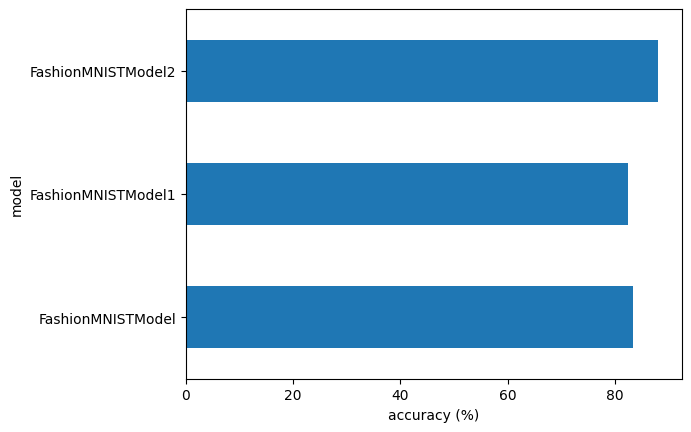

In [51]:
# Plotting Performance-Speed tradeoff
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

# **Making predictions with trained model_2**

In [52]:
# Making predictions with trained model_2
def make_predictions(model: torch.nn.Module, data: list, device: torch.device=device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logits = model(sample)

      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs) # Converts to tensor and adds extra dimension

In [53]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({classes[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [54]:
# Making predictions with trained model_2
pred_probs = make_predictions(model=model_2, data=test_samples)
pred_probs[:2]

tensor([[1.4021e-06, 1.7343e-07, 4.4511e-07, 1.2103e-05, 5.4026e-07, 9.9938e-01,
         3.7154e-06, 2.1650e-04, 1.4199e-04, 2.4416e-04],
        [1.0080e-01, 5.6287e-01, 7.4506e-04, 1.1212e-01, 6.3881e-02, 3.0674e-04,
         1.5560e-01, 1.6463e-03, 1.0169e-03, 1.0133e-03]])

In [55]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [56]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

# **Visualizing the predictions**

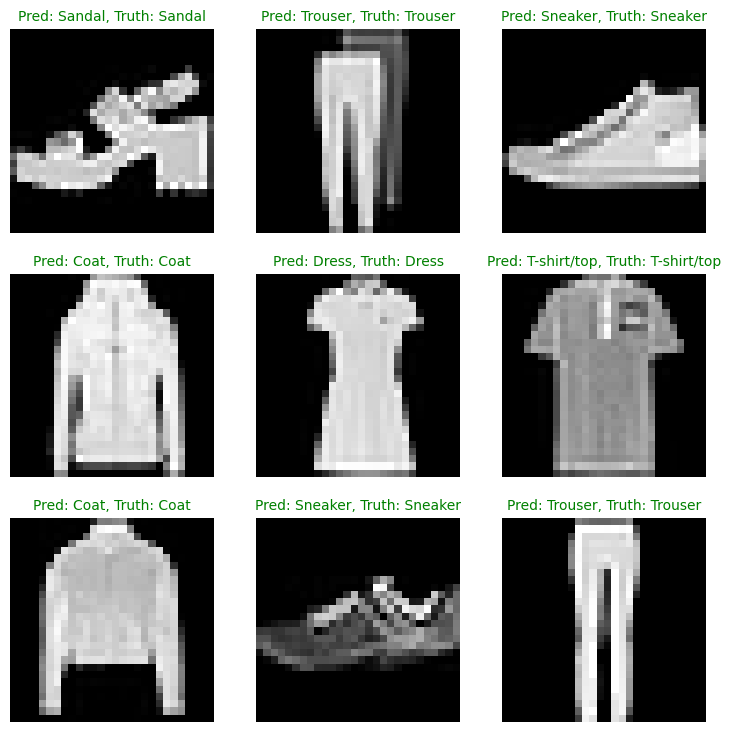

In [57]:
# Visualizing the predictions
plt.figure(figsize=(9, 9))
n_rows = 3
n_cols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(n_rows, n_cols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = classes[pred_classes[i]]

  truth_label = classes[test_labels[i]]

  title_text = f"Pred: {pred_label}, Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g")
  else:
    plt.title(title_text, fontsize=10, c="r")
  plt.axis(False)

# **Plotting the confusion matrix**

In [58]:
# Making predictions on all test data
from tqdm.auto import tqdm

y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    y_logits = model_2(X)

    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 5])

In [59]:
import mlxtend
print(mlxtend.__version__)

0.23.4


In [61]:
!pip install torchmetrics # run only if required

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.7 MB/s eta 0:00:00


In [62]:
# Importing torchmetrics and mlxtend
import torchmetrics

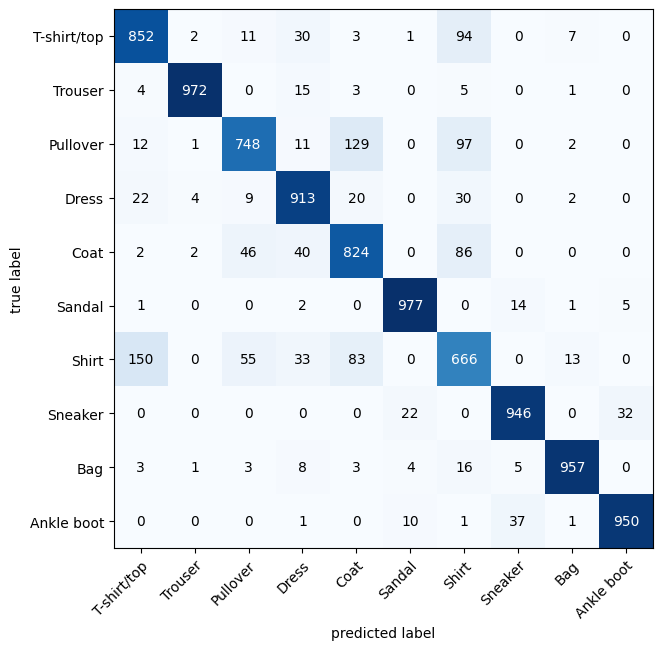

In [63]:
# Plotting the confusion matrix
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(classes), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(), class_names=classes, figsize=(10, 7))

# **Saving and Loading the model**

In [64]:
# Saving the model
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Pytorch_03_Computer_Vision_model_CNN.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/Pytorch_03_Computer_Vision_model_CNN.pth


In [65]:
# Loading the model
loaded_model_2 = FashionMNISTModel2(input_shape=1, hidden_units=10, output_shape=len(classes))

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_2.to(device)

loaded_model_2.state_dict()

OrderedDict([('block_1.0.weight',
              tensor([[[[ 0.3127,  0.3911, -0.4196],
                        [ 0.1556,  0.1815,  0.0878],
                        [-0.4420,  0.1430,  0.3166]]],
              
              
                      [[[-0.3738,  0.4791, -0.1338],
                        [ 0.2597,  0.4008,  0.0667],
                        [-0.1557,  0.3132,  0.0871]]],
              
              
                      [[[-0.3652, -0.0339, -0.0384],
                        [-0.6494, -0.6025,  0.2116],
                        [-0.8162, -0.6622, -0.1217]]],
              
              
                      [[[-0.7466, -0.8917, -0.7278],
                        [ 0.2914, -0.5231,  0.2517],
                        [ 0.2942, -0.0444,  0.3574]]],
              
              
                      [[[ 0.0132,  0.3515, -0.1108],
                        [-0.2418,  0.2368, -0.2215],
                        [-0.0970,  0.3388,  0.1292]]],
              
              
           

In [66]:
# Evalutating the loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(model=loaded_model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)

loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [67]:
model_2_results

{'model_name': 'FashionMNISTModel2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [68]:
# Checking if the results are close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]), torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, rtol=0.0001)

tensor(True)